# O1 fixed-depth performance across instance counts

This notebook compares fixed RF depths 5, 8, 12, 15, and 20 under 0% random-design injection. Each instance count gets its own best-regret confidence plot and final-regret boxplot.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DEPTHS = (5, 8, 12, 15, 20)
INSTANCE_COUNTS = (1, 2, 5, 10, 20, 50)
SMAC_SEEDS = tuple(range(5))
N_TRIALS = 2500
candidates = [Path.cwd(), Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/07_different_instance_numbers']
HERE = next((path for path in candidates if (path / 'o1_instance_count_runner.py').exists()), None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())


/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/07_different_instance_numbers


## Load, validate, and audit completeness

In [2]:
rows, curves = [], {}
for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    n_instances = int(data['n_instances']); depth = int(data['max_depth']); seed = int(data['smac_seed'])
    best = np.asarray(data['best_regret'], dtype=float)
    key = (n_instances, depth, seed)
    if key in curves: raise ValueError(f'Duplicate trajectory: {key}')
    curves[key] = best
    rows.append({
        'n_instances': n_instances, 'depth': depth, 'smac_seed': seed,
        'final_regret': float(best[-1]), 'mean_regret': float(best.mean()),
        'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
        'n_trials': int(data['n_trials']), 'dimension': int(data['dimension']),
        'problem_seed': int(data['problem_seed']),
        'random_design_probability': float(data['random_design_probability']),
        'pythonhashseed': str(data['pythonhashseed']), 'path': path,
    })
results = pd.DataFrame(rows)
if results.empty: raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')
bad = results.query("n_trials != 2500 or dimension != 10 or problem_seed != 52 or random_design_probability != 0 or pythonhashseed != '12345'")
if not bad.empty: display(bad); raise ValueError('Incompatible trajectory metadata.')
expected = {(instances, depth, seed) for instances in INSTANCE_COUNTS for depth in DEPTHS for seed in SMAC_SEEDS}
observed = set(curves)
print(f'Loaded {len(observed)}/{len(expected)} trajectories.')
if expected - observed:
    display(pd.DataFrame(sorted(expected - observed), columns=['n_instances','depth','smac_seed']))
display(results.groupby(['n_instances','depth']).smac_seed.nunique().unstack(fill_value=0).reindex(index=INSTANCE_COUNTS, columns=DEPTHS))


Loaded 150/150 trajectories.


depth,5,8,12,15,20
n_instances,,,,,
1,5,5,5,5,5
2,5,5,5,5,5
5,5,5,5,5,5
10,5,5,5,5,5
20,5,5,5,5,5
50,5,5,5,5,5


## Best-regret trajectories with 95% confidence intervals

Each line is the mean incumbent simple regret over five SMAC seeds. Shaded regions are two-sided 95% Student-t confidence intervals for that mean. All six figures use the same logarithmic y-axis limits so their vertical positions are directly comparable.

Shared trajectory y-limits: (np.float64(923.2696281793583), np.float64(517769.36965287))


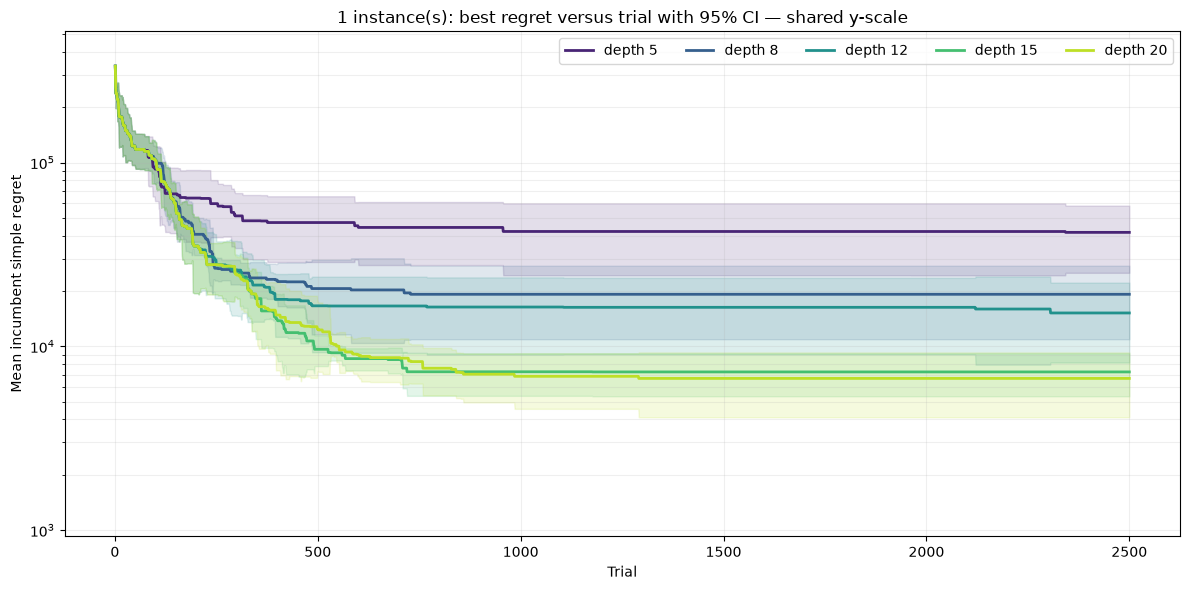

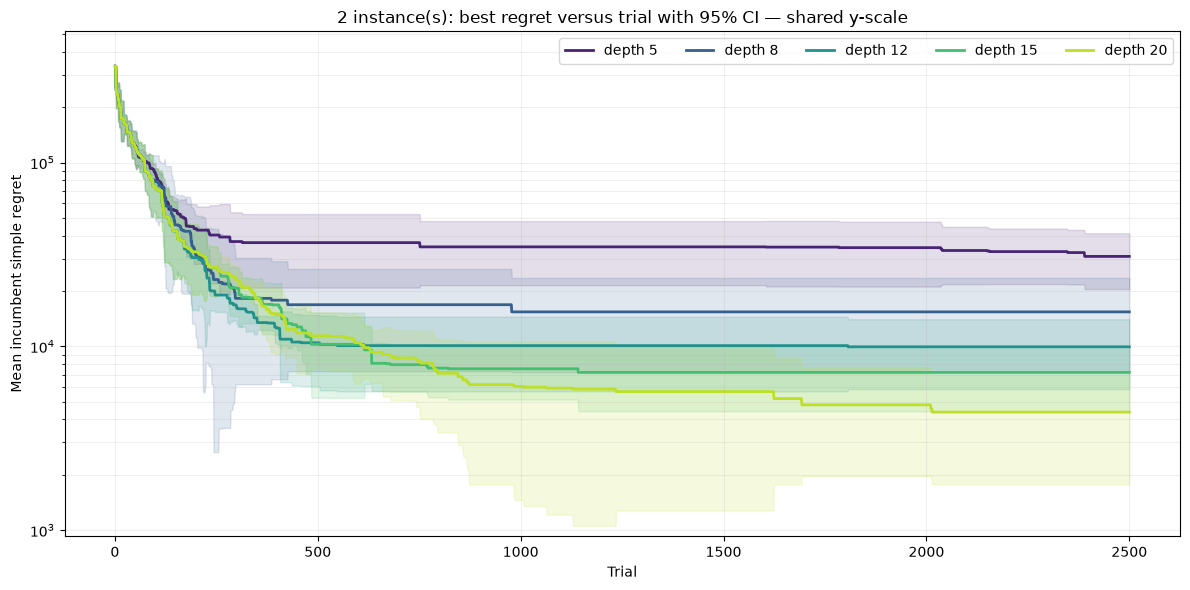

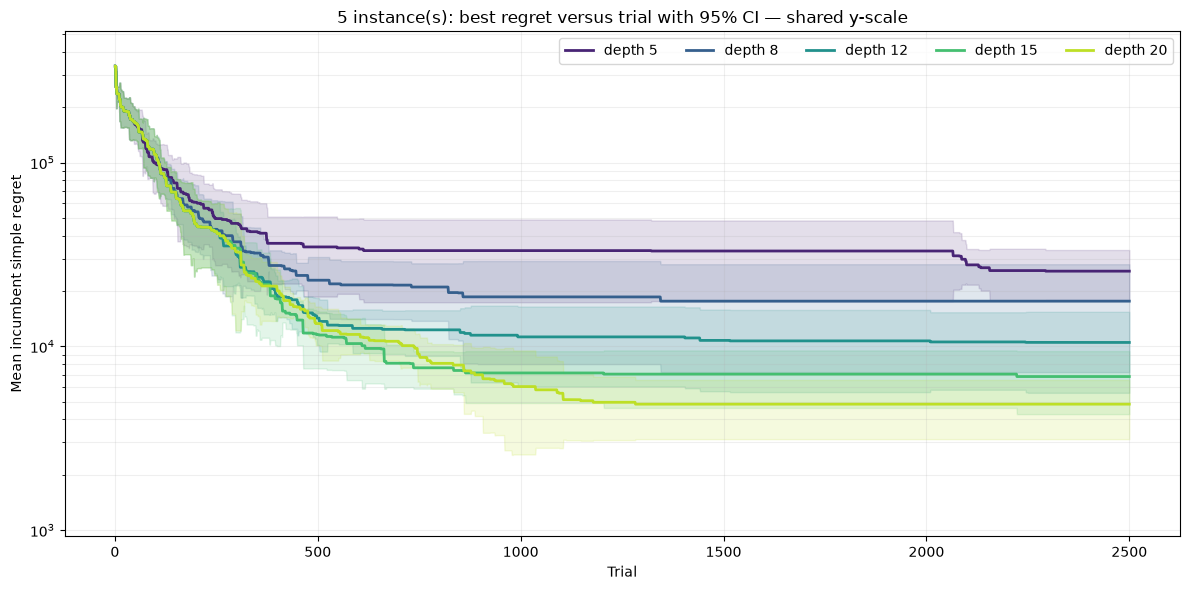

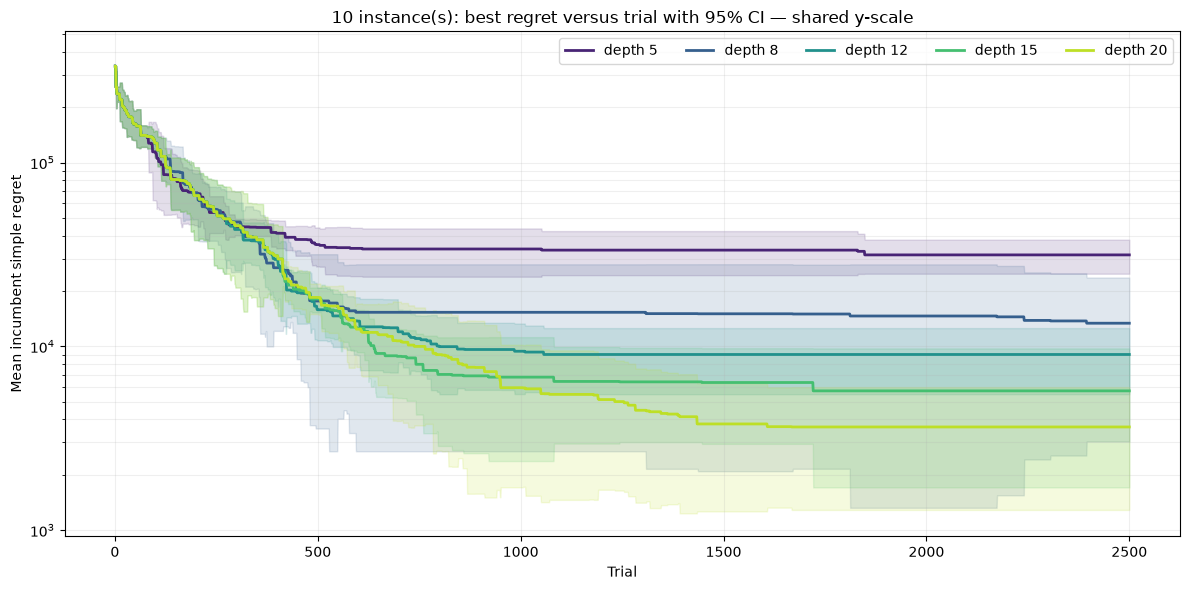

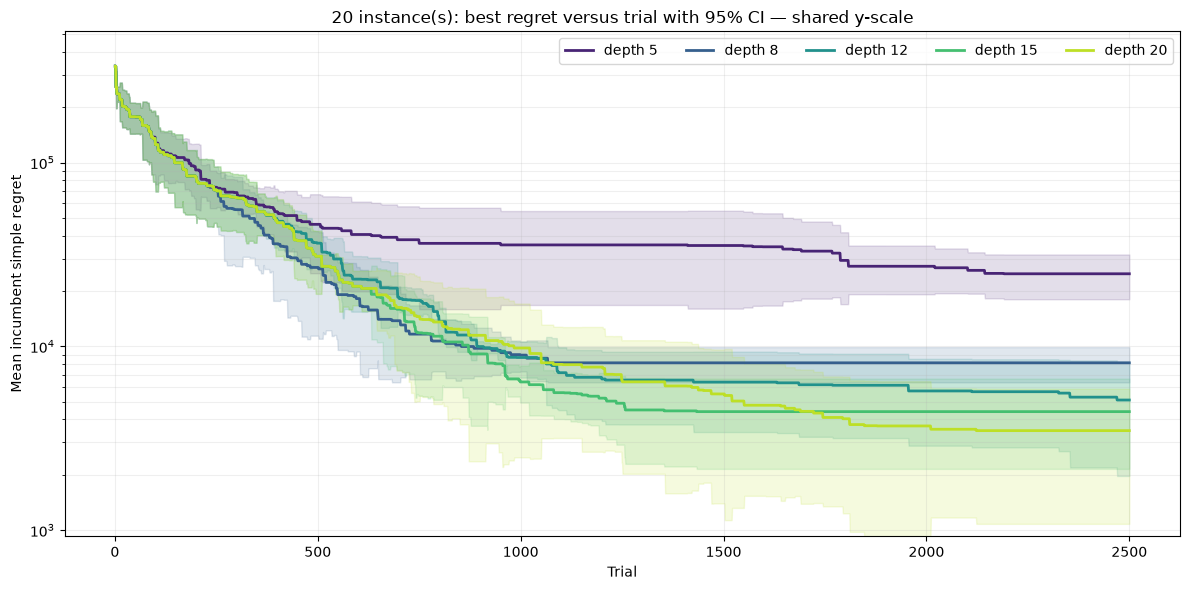

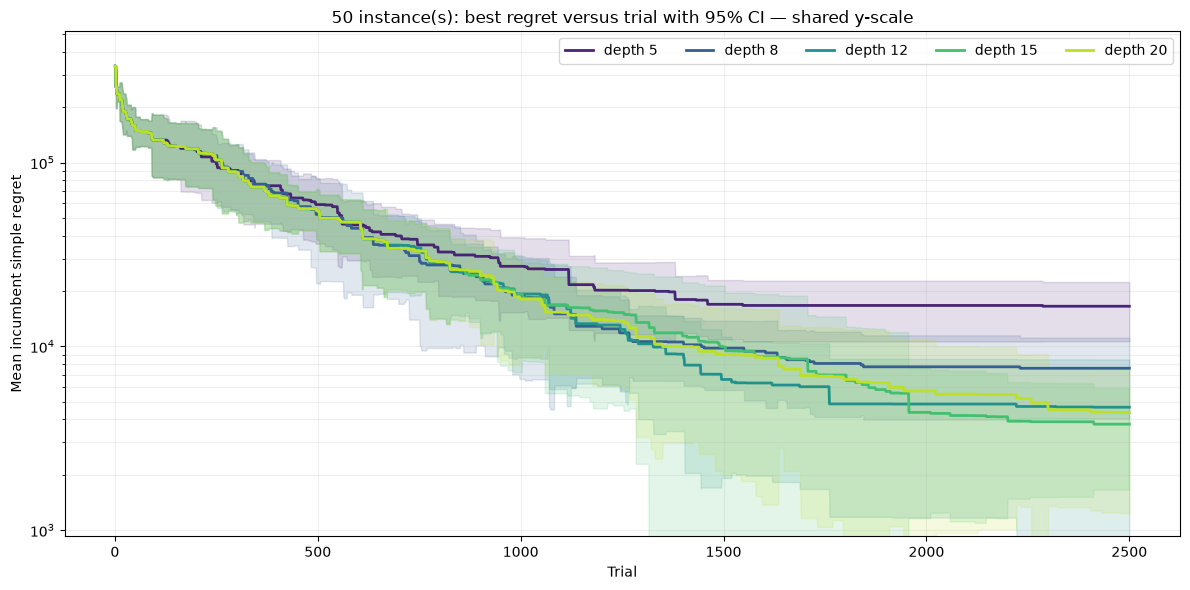

In [3]:
colors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(.1, .9, len(DEPTHS)))))
x = np.arange(1, N_TRIALS + 1)
def padded_log_limits(values, padding_decades=.08):
    positive = np.concatenate([np.asarray(value, float).ravel() for value in values])
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if not len(positive): raise ValueError('Cannot determine logarithmic limits without positive values.')
    low, high = np.log10(positive.min()), np.log10(positive.max())
    padding = max((high - low) * padding_decades, .05)
    return 10 ** (low - padding), 10 ** (high + padding)
trajectory_y_limits = padded_log_limits(list(curves.values()))
print('Shared trajectory y-limits:', trajectory_y_limits)
for n_instances in INSTANCE_COUNTS:
    missing = [(n_instances, depth, seed) for depth in DEPTHS for seed in SMAC_SEEDS if (n_instances, depth, seed) not in curves]
    if missing:
        print(f'Skipping {n_instances} instances; {len(missing)} trajectories are missing.')
        continue
    fig, ax = plt.subplots(figsize=(12, 6))
    for depth in DEPTHS:
        matrix = np.vstack([curves[(n_instances, depth, seed)] for seed in SMAC_SEEDS])
        mean = matrix.mean(axis=0)
        sem = matrix.std(axis=0, ddof=1) / np.sqrt(len(SMAC_SEEDS))
        margin = t.ppf(.975, len(SMAC_SEEDS) - 1) * sem
        lower = np.maximum(mean - margin, 1e-300); upper = np.maximum(mean + margin, 1e-300)
        ax.plot(x, np.maximum(mean, 1e-300), color=colors[depth], lw=2, label=f'depth {depth}')
        ax.fill_between(x, lower, upper, color=colors[depth], alpha=.15)
    ax.set_yscale('log'); ax.set_ylim(*trajectory_y_limits); ax.set_xlabel('Trial'); ax.set_ylabel('Mean incumbent simple regret')
    ax.set_title(f'{n_instances} instance(s): best regret versus trial with 95% CI — shared y-scale')
    ax.legend(ncol=5); ax.grid(alpha=.2, which='both'); plt.tight_layout(); plt.show()


## Final-regret boxplots

Each box contains the five final regrets from the paired SMAC seeds. Every instance count is shown in a separate plot, and all six boxplots use the same logarithmic y-axis limits. These final-only limits are separate from the trajectory limits so early-run regret does not compress the boxes.

Shared final-regret y-limits: (np.float64(1052.861740682208), np.float64(87914.11740491069))


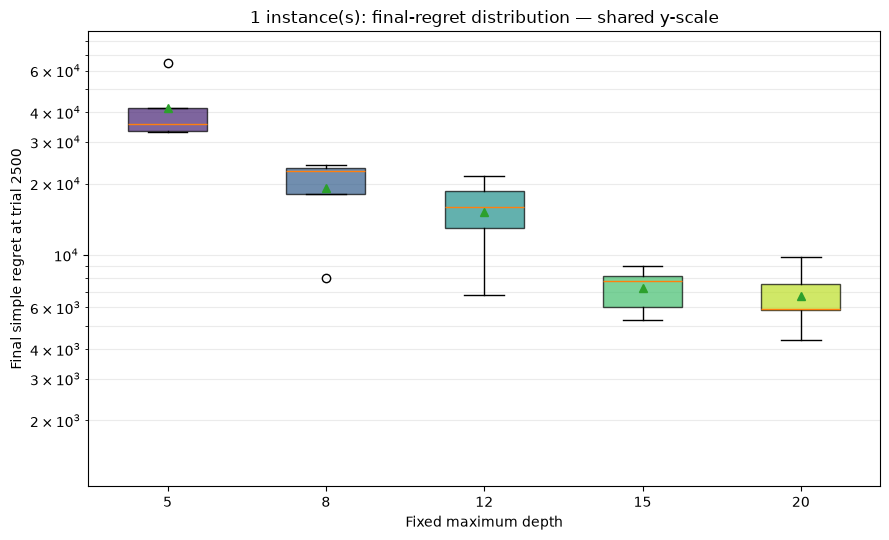

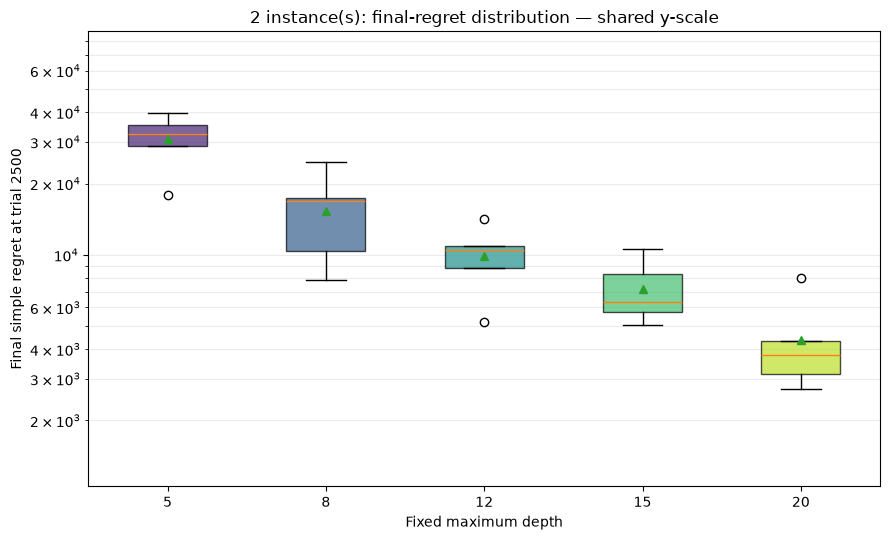

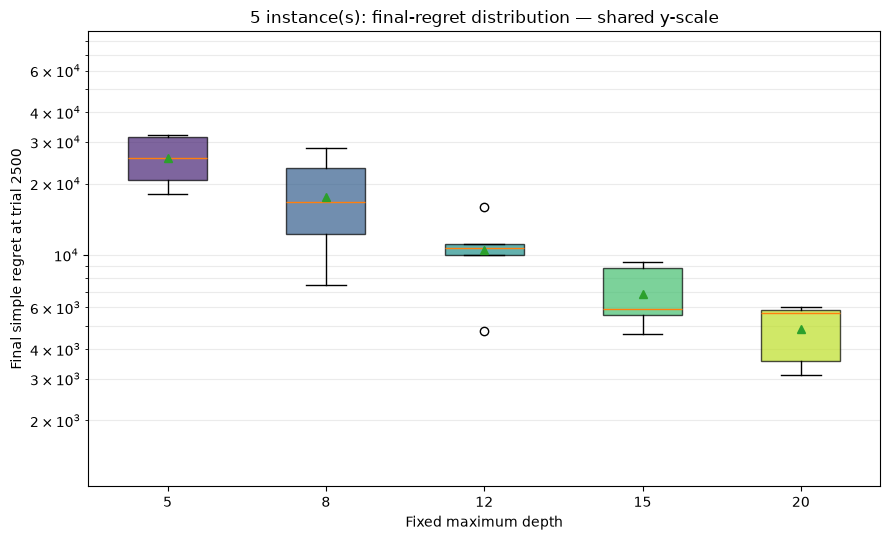

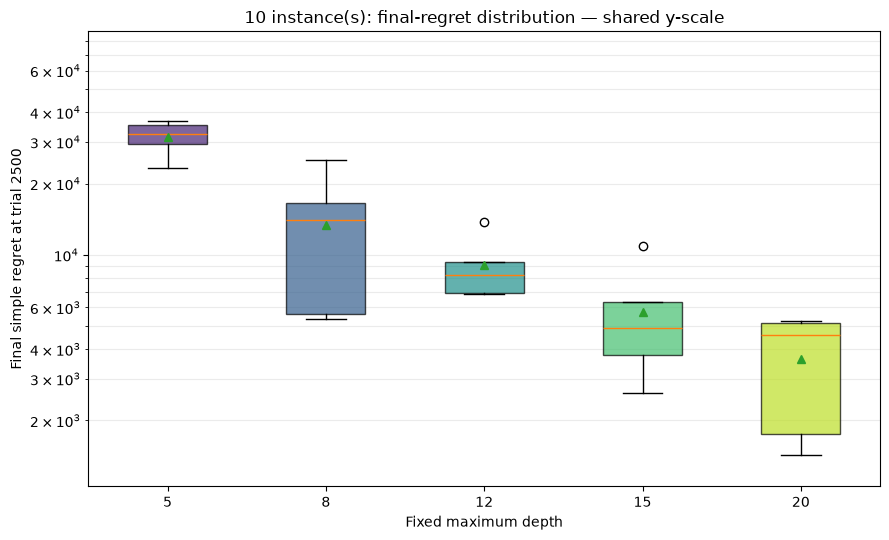

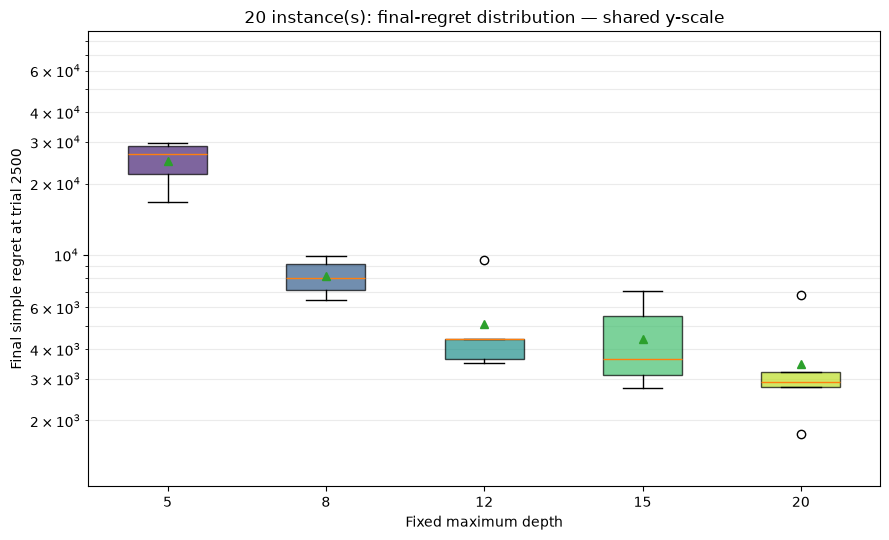

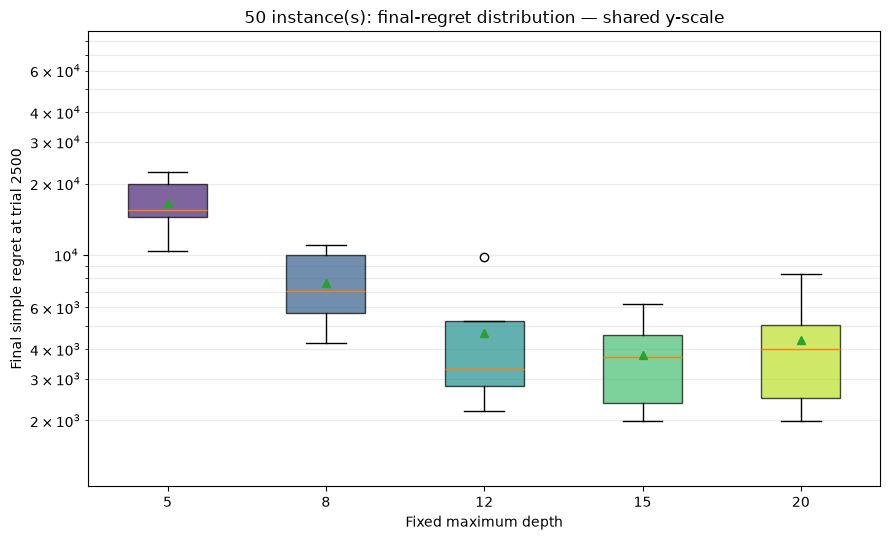

In [4]:
final_y_limits = padded_log_limits([results.final_regret.to_numpy()])
print('Shared final-regret y-limits:', final_y_limits)
for n_instances in INSTANCE_COUNTS:
    subset = results.query('n_instances == @n_instances')
    if any(subset.query('depth == @depth').smac_seed.nunique() != len(SMAC_SEEDS) for depth in DEPTHS):
        print(f'Skipping {n_instances} instances; fixed-depth results are incomplete.')
        continue
    values = [subset.query('depth == @depth').sort_values('smac_seed').final_regret.to_numpy() for depth in DEPTHS]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    boxes = ax.boxplot(values, tick_labels=[str(depth) for depth in DEPTHS], showmeans=True, patch_artist=True)
    for box, depth in zip(boxes['boxes'], DEPTHS): box.set_facecolor(colors[depth]); box.set_alpha(.7)
    ax.set_yscale('log'); ax.set_ylim(*final_y_limits); ax.set_xlabel('Fixed maximum depth'); ax.set_ylabel('Final simple regret at trial 2500')
    ax.set_title(f'{n_instances} instance(s): final-regret distribution — shared y-scale')
    ax.grid(axis='y', alpha=.25, which='both'); plt.tight_layout(); plt.show()


## Numerical summaries

,n_instances,depth,runs,mean_final,median_final,std_final,mean_log_auc,mean_regret,rank_within_instance_count
4,1,20,5,6691.860343,5941.091487,2076.693683,3.975349,16133.407151,1.0
3,1,15,5,7258.265849,7778.328238,1539.219342,3.994605,16310.093159,2.0
2,1,12,5,15193.560297,15992.167039,5659.707921,4.261004,23737.484796,3.0
1,1,8,5,19199.471454,22642.297586,6658.386129,4.327779,26719.038310,4.0
0,1,5,5,41706.979617,35780.993159,13357.124042,4.652954,48734.802342,5.0
9,2,20,5,4386.841093,3765.151170,2100.357717,3.867116,14258.357583,1.0
8,2,15,5,7215.783082,6345.241352,2243.326189,3.986490,15521.069709,2.0
7,2,12,5,9942.807372,10503.699888,3298.300858,4.070165,17100.979119,3.0
6,2,8,5,15401.969440,16844.727293,6571.073891,4.227312,22489.296658,4.0
5,2,5,5,30860.750109,32302.034712,8353.248355,4.553671,39884.301612,5.0


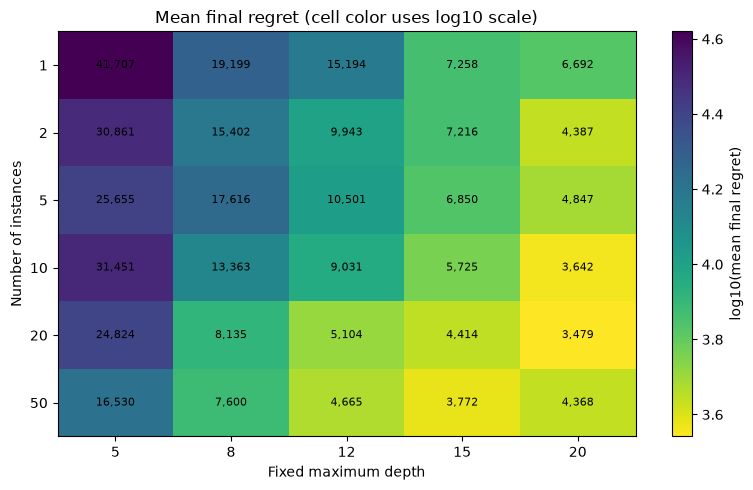

In [5]:
summary = (results.groupby(['n_instances','depth'], as_index=False)
    .agg(runs=('smac_seed','nunique'), mean_final=('final_regret','mean'), median_final=('final_regret','median'),
         std_final=('final_regret','std'), mean_log_auc=('log_auc','mean'), mean_regret=('mean_regret','mean')))
summary['rank_within_instance_count'] = summary.groupby('n_instances').mean_final.rank(method='average')
display(summary.sort_values(['n_instances','mean_final']))
mean_heatmap = summary.pivot(index='n_instances', columns='depth', values='mean_final').reindex(index=INSTANCE_COUNTS, columns=DEPTHS)
fig, ax = plt.subplots(figsize=(8, 5)); image = ax.imshow(np.log10(mean_heatmap), aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(DEPTHS)), DEPTHS); ax.set_yticks(range(len(INSTANCE_COUNTS)), INSTANCE_COUNTS)
ax.set_xlabel('Fixed maximum depth'); ax.set_ylabel('Number of instances'); ax.set_title('Mean final regret (cell color uses log10 scale)')
for i in range(len(INSTANCE_COUNTS)):
    for j in range(len(DEPTHS)): ax.text(j, i, f'{mean_heatmap.iloc[i,j]:,.0f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='log10(mean final regret)'); plt.tight_layout(); plt.show()


## Interpretation notes

- Compare which fixed depth is best at each instance count and whether the ordering changes.
- Look for instance counts where fixed depths separate clearly relative to their confidence bands and seed variance.
- Confidence intervals contain only five SMAC seeds and should be treated as descriptive.
- Because the instance sets are nested, changes with instance count are easier to attribute to the number of instances rather than entirely different instance samples.